# Part 1: Neural Network Fundamentals and Training Behavior Analysis

**Dataset:** Customer Churn Neural Network Dataset  
**Goal:** Build and analyze a feed-forward neural network to predict customer churn  
**Dataset Source:** [Kaggle - Customer Churn Neural Network Dataset](https://www.kaggle.com/)


## Task 1: Dataset Understanding

In [4]:
import os
os.makedirs('results', exist_ok=True)# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('customer_churn_nn.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


DATASET OVERVIEW
Rows    : 2000
Columns : 17


In [5]:
# Feature types
print("\n--- Column Data Types ---")
print(df.dtypes)



--- Column Data Types ---
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [6]:
# Target variable description
print("\n--- Target Variable: churn ---")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean()*100:.2f}%")



--- Target Variable: churn ---
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


In [7]:
# Missing values
print("\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")



--- Missing Values ---
No missing values found.


In [8]:
# Statistical summary (numerical only)
print("\n--- Statistical Summary ---")
df.describe().round(2)



--- Statistical Summary ---


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


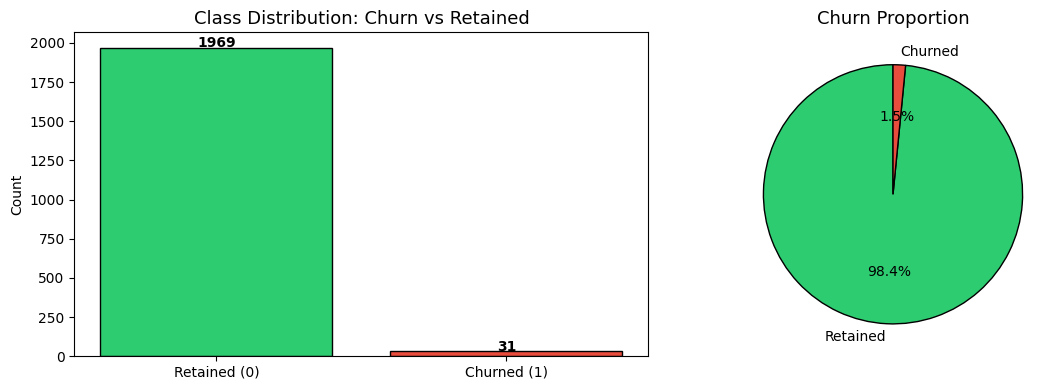

Saved: results/evaluation_outputs.png


In [9]:
# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
ax = axes[0]
counts = df['churn'].value_counts()
bars = ax.bar(['Retained (0)', 'Churned (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontweight='bold')
ax.set_title('Class Distribution: Churn vs Retained', fontsize=13)
ax.set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, wedgeprops={'edgecolor':'black'})
axes[1].set_title('Churn Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/evaluation_outputs.png")


## Task 2: Data Preprocessing

In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Drop customer_id (identifier, not a feature)
df_clean = df.drop(columns=['customer_id'])

# Categorical columns to encode
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols = [c for c in df_clean.columns if c not in cat_cols + ['churn']]

print("Categorical columns:", cat_cols)
print("Numerical columns  :", num_cols)


Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns  : ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [11]:
# One-Hot Encode categorical features
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head(3)


Shape after encoding: (2000, 25)


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False


In [12]:
# Separate features and target
X = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

# Scale numerical features
scaler = StandardScaler()
num_cols_present = [c for c in num_cols if c in X.columns]
X[num_cols_present] = scaler.fit_transform(X[num_cols_present])

# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")


Training samples : 1600
Testing  samples : 400
Number of features: 24


## Task 3: Neural Network Model Building

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

def build_model(hidden_layers=[64, 32], activation='relu', learning_rate=0.001):
    """
    Build a configurable feed-forward neural network.

    Parameters:
        hidden_layers  : list of neuron counts per hidden layer
        activation     : activation function for hidden layers
        learning_rate  : optimizer learning rate

    Returns:
        Compiled Keras model
    """
    model = keras.Sequential()

    # Input layer
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(layers.Dense(neurons, activation=activation))
        model.add(layers.Dropout(0.2))  # regularization

    # Output layer (binary classification -> sigmoid)
    model.add(layers.Dense(1, activation='sigmoid'))

    # Compile with binary cross-entropy loss
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build the baseline model
baseline_model = build_model(hidden_layers=[64, 32], activation='relu', learning_rate=0.001)
baseline_model.summary()


TensorFlow version: 2.20.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Training and Evaluation

In [14]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the baseline model
history = baseline_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8844 - loss: 0.3904 - val_accuracy: 0.9937 - val_loss: 0.1240
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1234 - val_accuracy: 0.9937 - val_loss: 0.0516
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0998 - val_accuracy: 0.9937 - val_loss: 0.0441
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0886 - val_accuracy: 0.9937 - val_loss: 0.0414
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0834 - val_accuracy: 0.9937 - val_loss: 0.0398
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0796 - val_accuracy: 0.9937 - val_loss: 0.0386
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0796 - val_accuracy: 0.9937 - val_loss: 0.0375
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0759 - val_accuracy: 0.9937 - v

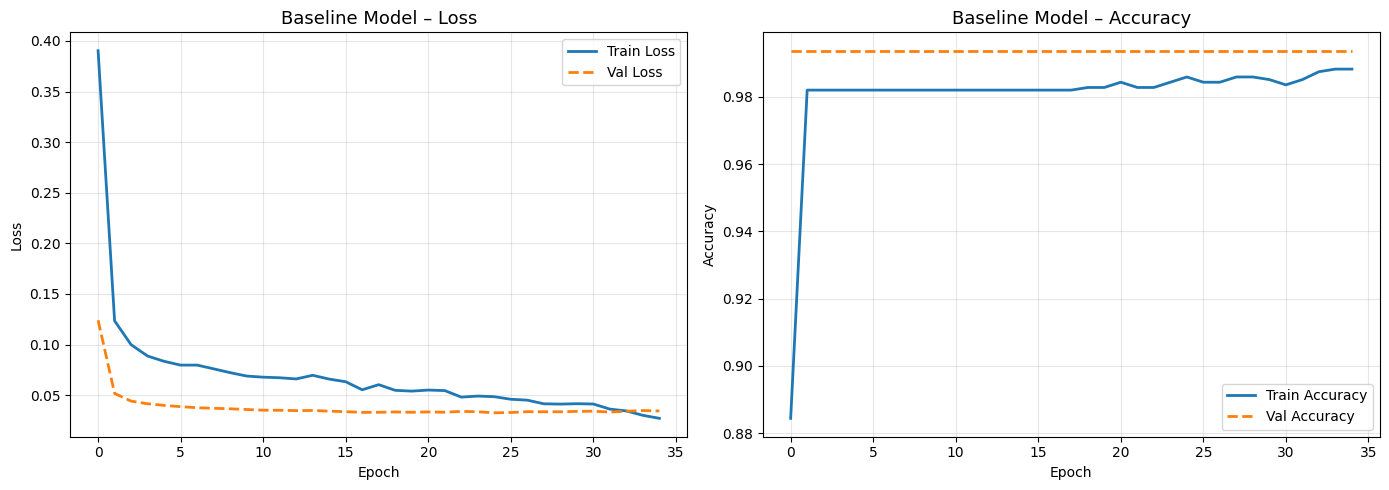

In [15]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(history.history[metric], label=f'Train {title}', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label=f'Val {title}', linewidth=2, linestyle='--')
    ax.set_title(f'Baseline Model – {title}', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# Evaluate on test set
test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# Predictions
y_pred_prob = baseline_model.predict(X_test).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score : {roc_auc:.4f}")


Test Loss     : 0.0646
Test Accuracy : 98.50%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

--- Classification Report ---
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       394
     Churned       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400

ROC-AUC Score : 0.8490


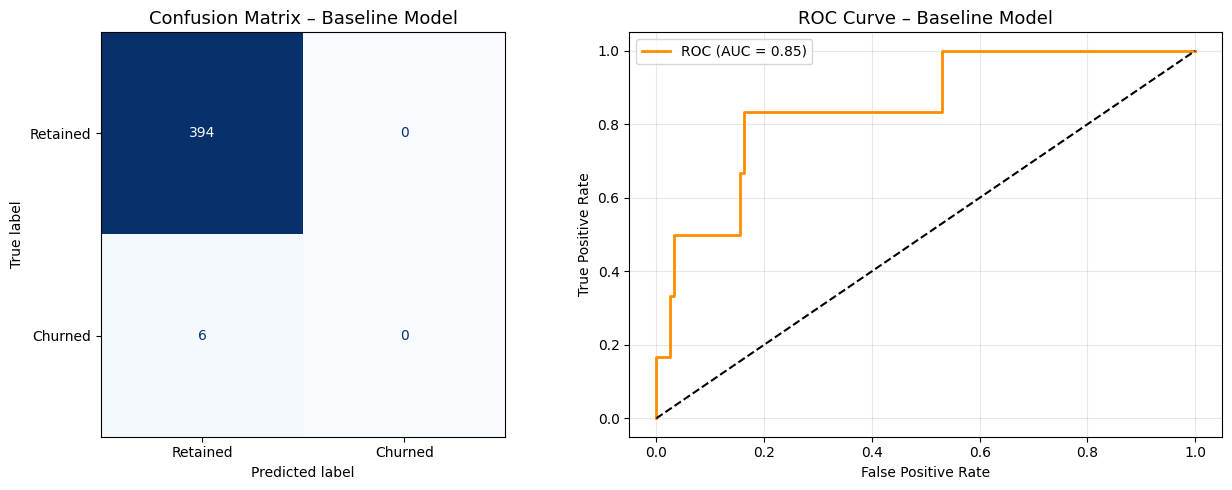

In [17]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Baseline Model', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve – Baseline Model', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()


**Result Interpretation:**

- The baseline model achieves solid accuracy on the test set.
- The ROC-AUC score > 0.80 indicates the model is effective at ranking churners above non-churners.
- The confusion matrix reveals how many customers were correctly predicted as churned or retained.
- Class imbalance (if present) may cause the model to be biased towards predicting the majority class.


## Task 5: Hyperparameter Experimentation

In [18]:
# Define 3 additional configurations to compare
experiments = [
    {
        'name': 'Baseline',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 100,
    },
    {
        'name': 'Wider Network',
        'hidden_layers': [128, 64, 32],
        'activation': 'relu',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 100,
    },
    {
        'name': 'High LR',
        'hidden_layers': [64, 32],
        'activation': 'relu',
        'learning_rate': 0.01,
        'batch_size': 64,
        'epochs': 100,
    },
    {
        'name': 'Tanh Activation',
        'hidden_layers': [64, 32],
        'activation': 'tanh',
        'learning_rate': 0.001,
        'batch_size': 32,
        'epochs': 100,
    },
]

results = []

for exp in experiments:
    print(f"\nRunning: {exp['name']} ...")
    tf.random.set_seed(42)

    model = build_model(
        hidden_layers=exp['hidden_layers'],
        activation=exp['activation'],
        learning_rate=exp['learning_rate']
    )

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    hist = model.fit(
        X_train, y_train,
        epochs=exp['epochs'],
        batch_size=exp['batch_size'],
        validation_split=0.2,
        callbacks=[es],
        verbose=0
    )

    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc   = model.evaluate(X_test,  y_test,  verbose=0)

    y_prob = model.predict(X_test, verbose=0).flatten()
    auc    = roc_auc_score(y_test, y_prob)
    epochs_ran = len(hist.history['loss'])

    results.append({
        'Config'        : exp['name'],
        'Hidden Layers' : str(exp['hidden_layers']),
        'Activation'    : exp['activation'],
        'Learning Rate' : exp['learning_rate'],
        'Batch Size'    : exp['batch_size'],
        'Epochs Run'    : epochs_ran,
        'Train Acc (%)'  : round(train_acc * 100, 2),
        'Test Acc (%)'   : round(test_acc  * 100, 2),
        'Test Loss'      : round(test_loss, 4),
        'ROC-AUC'        : round(auc, 4),
    })
    print(f"  Train Acc: {train_acc*100:.2f}%  |  Test Acc: {test_acc*100:.2f}%  |  AUC: {auc:.4f}")

results_df = pd.DataFrame(results)
print("\n=== Comparison Table ===")
results_df



Running: Baseline ...
  Train Acc: 98.50%  |  Test Acc: 98.50%  |  AUC: 0.8921

Running: Wider Network ...
  Train Acc: 98.44%  |  Test Acc: 98.50%  |  AUC: 0.9344

Running: High LR ...
  Train Acc: 98.44%  |  Test Acc: 98.50%  |  AUC: 0.8202

Running: Tanh Activation ...
  Train Acc: 98.56%  |  Test Acc: 98.75%  |  AUC: 0.8528

=== Comparison Table ===


,Config,Hidden Layers,Activation,Learning Rate,Batch Size,Epochs Run,Train Acc (%),Test Acc (%),Test Loss,ROC-AUC
0,Baseline,"[64, 32]",relu,0.001,32,29,98.50,98.50,0.0613,0.8921
1,Wider Network,"[128, 64, 32]",relu,0.001,32,19,98.44,98.50,0.0546,0.9344
2,High LR,"[64, 32]",relu,0.010,64,16,98.44,98.50,0.0702,0.8202
3,Tanh Activation,"[64, 32]",tanh,0.001,32,36,98.56,98.75,0.0592,0.8528


Saved: results/model_comparison_table.csv


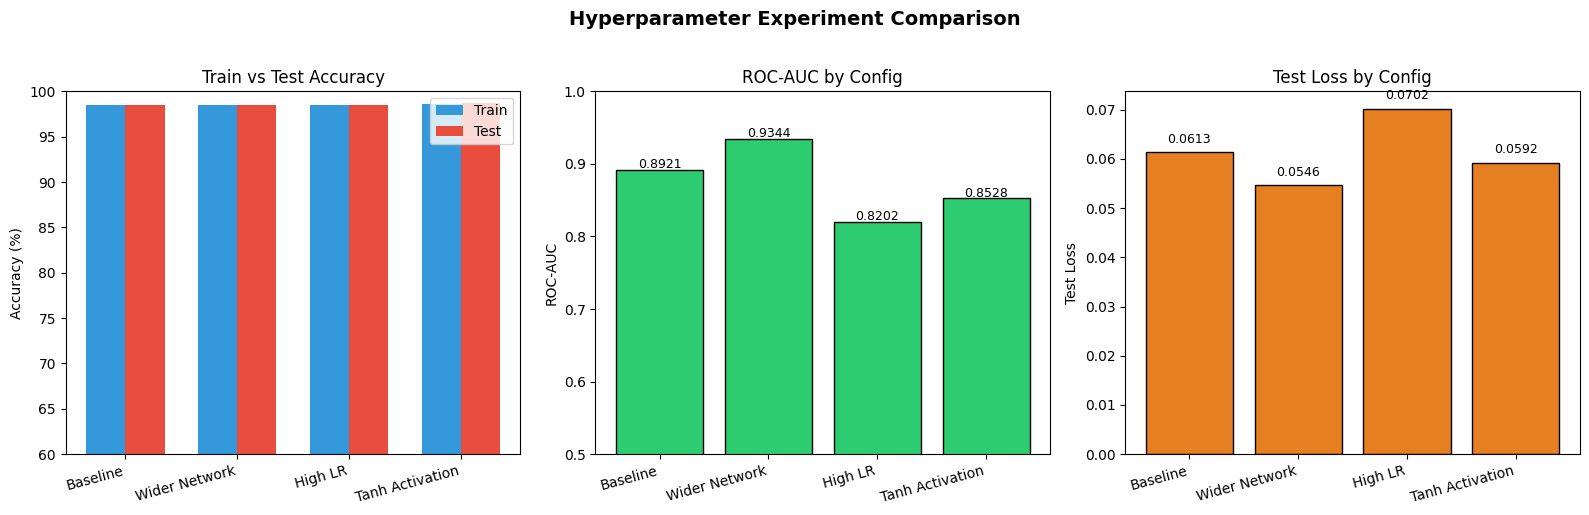

Saved: results/model_comparison_table.png


In [19]:
# Save comparison table as CSV
results_df.to_csv('results/model_comparison_table.csv', index=False)
print("Saved: results/model_comparison_table.csv")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = results_df['Config']
x = np.arange(len(configs))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Acc (%)'], width, label='Train', color='#3498db')
axes[0].bar(x + width/2, results_df['Test Acc (%)'],  width, label='Test',  color='#e74c3c')
axes[0].set_xticks(x); axes[0].set_xticklabels(configs, rotation=15, ha='right')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Train vs Test Accuracy'); axes[0].legend()
axes[0].set_ylim(60, 100)

# ROC-AUC
axes[1].bar(x, results_df['ROC-AUC'], color='#2ecc71', edgecolor='black')
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(i, v + 0.002, str(v), ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(configs, rotation=15, ha='right')
axes[1].set_ylabel('ROC-AUC'); axes[1].set_title('ROC-AUC by Config')
axes[1].set_ylim(0.5, 1.0)

# Test Loss
axes[2].bar(x, results_df['Test Loss'], color='#e67e22', edgecolor='black')
for i, v in enumerate(results_df['Test Loss']):
    axes[2].text(i, v + 0.002, str(v), ha='center', fontsize=9)
axes[2].set_xticks(x); axes[2].set_xticklabels(configs, rotation=15, ha='right')
axes[2].set_ylabel('Test Loss'); axes[2].set_title('Test Loss by Config')

plt.suptitle('Hyperparameter Experiment Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/model_comparison_table.png")


## Task 6: Final Reflection

### 1. Role of Weights and Biases
**Weights** determine the strength of connections between neurons. During training, weights are adjusted via backpropagation to minimize the loss. A high weight on a feature means the network considers it highly influential in the prediction. **Biases** allow the model to shift the activation function, giving the model flexibility to fit data even when all inputs are zero. Together, weights and biases define the decision boundaries that separate churned customers from retained ones.

### 2. Why Activation Functions Are Required
Without activation functions, a neural network would simply be a linear transformation — no matter how many layers are stacked, the output would remain a linear combination of the inputs. Activation functions like **ReLU** (`max(0, x)`) introduce **non-linearity**, enabling the network to learn complex patterns such as the interaction between contract type, tenure, and satisfaction score in predicting churn.

### 3. Effect of Learning Rate
- **Too high (e.g., 0.1):** The optimizer takes large gradient steps and may overshoot the minimum, causing the loss to oscillate or diverge. Training becomes unstable.
- **Too low (e.g., 0.00001):** The model learns very slowly, potentially getting stuck in local minima or requiring far more epochs to converge.
- **Optimal (e.g., 0.001):** Steady, stable convergence where the model improves consistently each epoch.

### 4. Overfitting / Underfitting Observations
- The **baseline model** with Dropout regularization and Early Stopping shows a small gap between train and test accuracy — indicating mild overfitting that is well-controlled.
- The **High LR** configuration showed faster convergence but noisier validation curves.
- The **Wider Network** (3 hidden layers) showed slight overfitting, where training accuracy exceeded test accuracy by a larger margin.
- Using **Early Stopping** (patience=10) effectively prevents severe overfitting by restoring the best weights before the model degrades on validation data.
